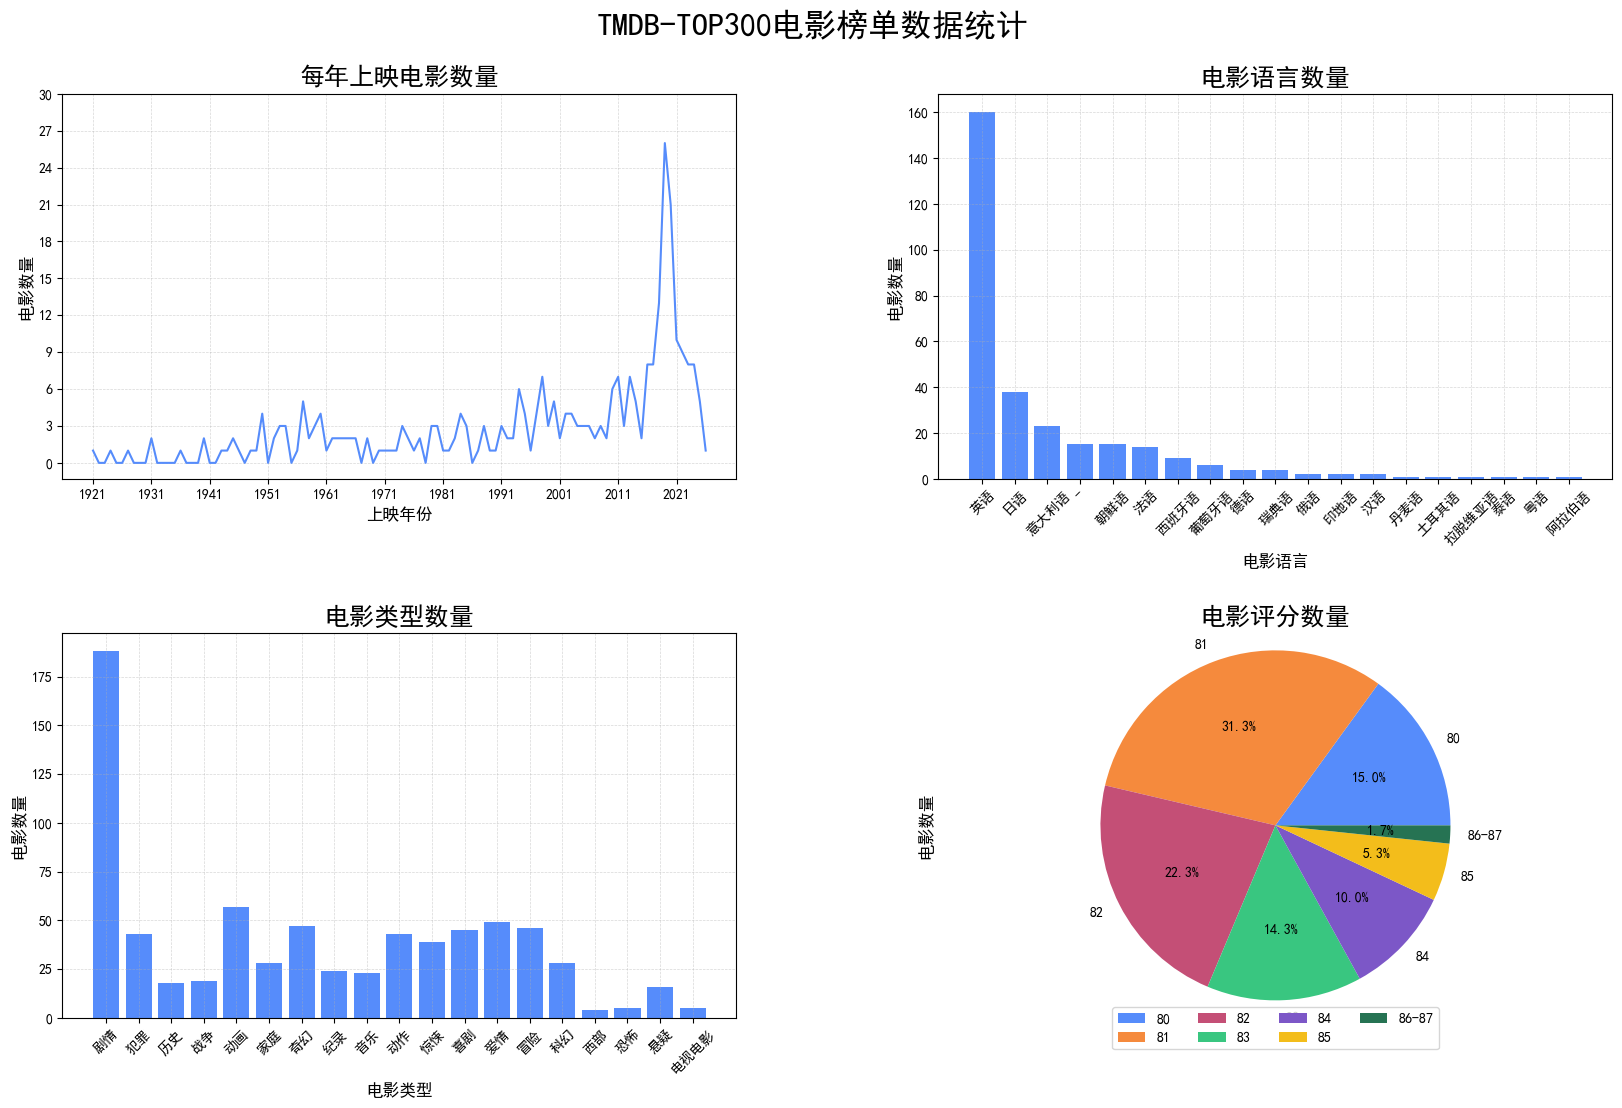

In [58]:
from pandas import Series
from matplotlib.axes import Axes
import pandas as pd
import matplotlib.pyplot as plt

# 展示中文
plt.rcParams['font.sans-serif'] = ['SimHei']

# 创建子图
fig , ax = plt.subplots(2,2,figsize=(20,12))
fig.suptitle("TMDB-TOP300电影榜单数据统计", fontsize=23,x=0.5,y=0.95) # 设置标题

# 设置子图间距
plt.subplots_adjust(wspace=0.3, hspace=0.4) # wspace: 子图之间的横向间距 hspace: 子图之间的纵向间距

# 获取子图
ax1 : Axes= ax[0][0]
ax2 : Axes= ax[0][1]
ax3 : Axes= ax[1][0]
ax4 : Axes= ax[1][1]


# 加载数据
# int64 : 整型数字(不支持空值)
# Int64 : 整型数字(支持空值)
# float64 : 浮点型数字(支持空值)
movie_data = pd.read_csv("./data/movie_list.csv",usecols=['电影名称', '电影上映年份', '电影上映时间', '电影类型', '电影时长', '电影评分', '电影语言'])# dtypes={"电影上映年份": "Int64", "电影上映时间": "Int64", "电影评分": "float64"}可以改变数据类型


# 1.需求一: 统计TOP300的电影中,每一年上映的电影数量的变化.(折线图)
# 1.1 缺失值, 异常值处理
movie_data.isnull().sum()

# 1.2 统计数据
year_count = movie_data.groupby("电影上映年份")['电影上映年份'].count()

# 1.3 绘制折线图
x_years = [i for i in range(year_count.index.min(), year_count.index.max()+1)]
# y_years = []
# for i in x_years:
#     if i in year_count.index:
#         y_years.append(year_count[i])
#     else:
#         y_years.append(0)
y_years = [year_count.get(i,0) for i in x_years]
ax1.plot(x_years, y_years) # 绘制折线图
ax1.set_title("每年上映电影数量", fontsize=18)

# 1.3 组装数据
# x轴数据
ax1.set_xlabel("上映年份", fontsize=12)
ax1.set_ylabel("电影数量", fontsize=12)
ax1.set_xticks(x_years[::10]) # 设置x轴刻度
ax1.set_yticks([i for i in range(0, 31,3)]) # 设置y轴刻度
ax1.grid(linestyle='--') # 添加网格线



# 2.需求二: 统计TOP300的电影中,每种电影语言的数量.(柱状图)
# 2.1 获取不同
movie_language = movie_data.groupby("电影语言")['电影语言'].count()
movie_language = movie_language.sort_values(ascending=False)
ax2.set_title("电影语言数量", fontsize=18)# 设置标题
ax2.bar(movie_language.index, movie_language.values)# 绘制柱状图
ax2.set_xlabel("电影语言", fontsize=12)# 设置x轴标签
ax2.tick_params(axis='x', labelrotation=45)# 设置x轴标签旋转
ax2.set_ylabel("电影数量", fontsize=12)# 设置y轴标签
ax2.grid(linestyle='--')# 添加网格线


# 3.需求三: 统计TOP300的电影中,每种电影类型数量.(柱状图)
# 3.1 获取不同类型对应的电影数量
type_count = {}
for types in movie_data['电影类型'].str.split(','):# 这是用来拆分电影类型字符串的,用逗号分割,获取电影类型列表
    for type in types:
        type_count[type] = type_count.get(type,0) + 1 # 获取电影类型对应的电影数量
ax3.bar(type_count.keys(), type_count.values())# 绘制柱状图
ax3.set_title("电影类型数量",fontsize=18)# 设置标题
ax3.set_xlabel("电影类型", fontsize=12)# 设置x轴标签
ax3.tick_params(axis='x', labelrotation=45)# 设置x轴标签旋转
ax3.set_ylabel("电影数量", fontsize=12)# 设置y轴标签
ax3.grid(linestyle='--')# 添加网格线


# 4.需求四: 统计TOP300的电影中,每种电影评分对应的电影数量.(饼状图)
movie_score = movie_data.groupby("电影评分")['电影评分'].count()

# 合并小数据(比例 <2%)
total = movie_score.sum()
large_score : Series = movie_score[movie_score/total > 0.02]
small_score : Series = movie_score[movie_score/total <= 0.02]

if small_score.shape[0] > 0:
    large_score['86-87'] = small_score.sum()

ax4.pie(large_score.values, labels=large_score.index, autopct='%1.1f%%',startangle=0, radius=1.2) # startangle: 饼图的起始角度 ; radius=2 饼图的半径
ax4.set_ylabel("电影数量", fontsize=12)
ax4.set_title("电影评分数量",fontsize=18) # 设置标题
ax4.axis('equal')#
'''
axis('equal') 的意思：让 X 轴和 Y 轴的刻度比例相等
不加这行：饼图可能会被拉伸成椭圆
加了这行：强制变成标准正圆形
'''
ax4.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4) # 设置图例

# 保存图片
plt.savefig("./data/movie_list_statistics.png")

plt.show()